# Comprehensive Dataset Analysis
This notebook provides a step-by-step analysis of the train, validation, and test datasets for temporal graph neural networks. We will explore adjacency matrix properties, node features, homophily, up ratios, and more.

In [23]:
# Import required libraries
from dataset_analyzer import MarketAnalyzer
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Datasets
We load the train, validation, and test datasets using the MarketAnalyzer class.

In [24]:
MARKET = 'NASDAQ'
NORMALIZATION = 'zscore'
WINDOW_SIZE = 19

train_path = Path(f"/home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/{MARKET}_Train_2016-05-01_2017-06-30_{WINDOW_SIZE}_{NORMALIZATION}")
val_path = Path(f"/home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/{MARKET}_Validation_2017-07-01_2017-12-31_{WINDOW_SIZE}_{NORMALIZATION}")
test_path = Path(f"/home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/{MARKET}_Test_2018-01-01_2019-12-31_{WINDOW_SIZE}_{NORMALIZATION}")

train_analyzer = MarketAnalyzer(train_path)
val_analyzer = MarketAnalyzer(val_path)
test_analyzer = MarketAnalyzer(test_path)

|             Dataset Information             |
| Market Name:         NASDAQ                  |
| Time Period:         Train                   |
| Start Date:          2016-05-01              |
| End Date:            2017-06-30              |
| Window Size:         19                      |
| Normalizer:          zscore                  |
| Number of Features:  5                       |
| Number of Nodes:     721                     |
| Number of Snapshots: 208                     |
Folder analysis_results already exists at /home/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/NASDAQ_Train_2016-05-01_2017-06-30_19_zscore
|             Dataset Information             |
| Market Name:         NASDAQ                  |
| Time Period:         Validation              |
| Start Date:          2017-07-01              |
| End Date:            2017-12-31              |
| Window Size:         19                      |
| Normalizer:          zscore                  |
| Number of Featur

## Extract Snapshots Info
Get snapshot-level information for each dataset.

In [25]:
train_snapshots_info = train_analyzer.get_snapshots_info()
val_snapshots_info = val_analyzer.get_snapshots_info()
test_snapshots_info = test_analyzer.get_snapshots_info()

train_df = pd.DataFrame(train_snapshots_info)
train_df['dataset'] = 'train'
val_df = pd.DataFrame(val_snapshots_info)
val_df['dataset'] = 'validation'
test_df = pd.DataFrame(test_snapshots_info)
test_df['dataset'] = 'test'
all_snapshots_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

## Adjacency Matrix Analysis
Analyze properties of the adjacency matrices: density, connectivity, and degree distribution.

## Adjacency Matrix Values Legend
In our graph representation:
- **Edge weights**: Represent the correlation strength between stock price movements
- **0 values**: No edge between nodes (no significant correlation)
- **Positive values**: Positive correlation between stock price movements
- **Higher values**: Stronger correlation between stocks

The adjacency matrix is a key component that shows relationships between different stocks in the market graph.

Adjacency matrix shape: (721, 721)


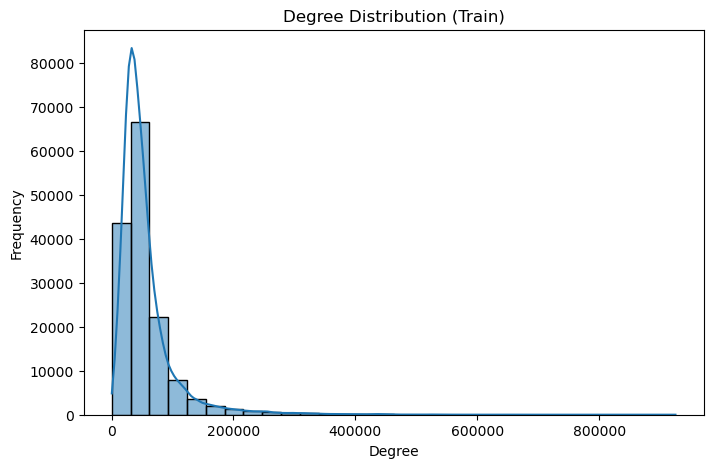

In [26]:
# Example: Plot degree distribution for train snapshots
adj_matrices = train_analyzer.get_snapshots_adjacency_matrix()
degrees = []
for adj in adj_matrices:
        deg = np.sum(adj, axis=1)
        degrees.extend(deg)
plt.figure(figsize=(8, 5))
sns.histplot(degrees, bins=30, kde=True)
plt.title('Degree Distribution (Train)')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()

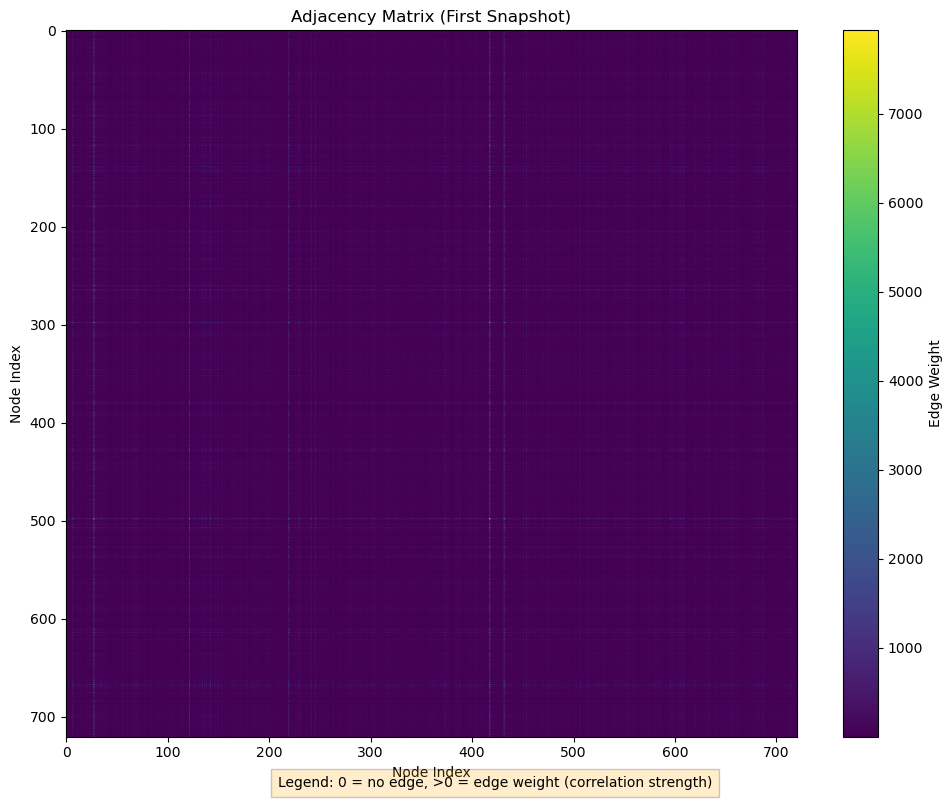

In [27]:
# Display the adjacency matrix with colorbar and legend
plt.figure(figsize=(10, 8))
im = plt.imshow(adj_matrices[0], cmap='viridis', aspect='auto')
plt.title('Adjacency Matrix (First Snapshot)')
plt.xlabel('Node Index')
plt.ylabel('Node Index')
plt.colorbar(im, label='Edge Weight')
plt.figtext(0.5, 0.01, "Legend: 0 = no edge, >0 = edge weight (correlation strength)", 
           ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
plt.tight_layout()
plt.show()

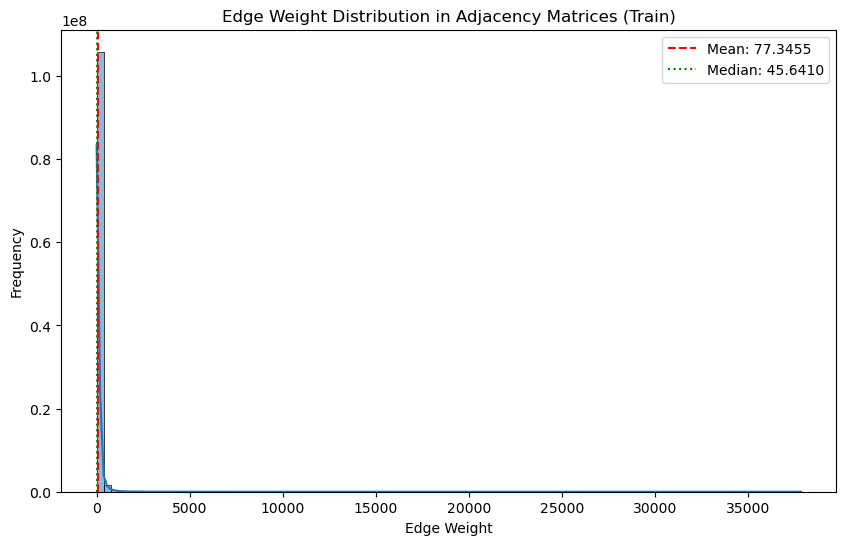

Edge Weight Statistics:
count    1.081269e+08
mean     7.734547e+01
std      1.515080e+02
min      5.381764e-02
25%      2.576703e+01
50%      4.564098e+01
75%      8.090678e+01
max      3.785300e+04
dtype: float64


In [28]:
# Analyze distribution of adjacency matrix values (edge weights)
edge_weights = []
for adj in adj_matrices:
    # Get only the non-zero values (actual edges)
    non_zero_weights = adj[adj > 0]
    if len(non_zero_weights) > 0:
        edge_weights.extend(non_zero_weights)

plt.figure(figsize=(10, 6))
sns.histplot(edge_weights, bins=100, kde=True)
plt.title('Edge Weight Distribution in Adjacency Matrices (Train)')
plt.xlabel('Edge Weight')
plt.ylabel('Frequency')
plt.axvline(np.mean(edge_weights), color='red', linestyle='--', label=f'Mean: {np.mean(edge_weights):.4f}')
plt.axvline(np.median(edge_weights), color='green', linestyle=':', label=f'Median: {np.median(edge_weights):.4f}')
plt.legend()
plt.show()

# Summary statistics of edge weights
edge_stats = pd.Series(edge_weights).describe()
print("Edge Weight Statistics:")
print(edge_stats)

In [29]:
adj_matrices[0].mean(axis=1)

array([ 52.11906  ,  62.400436 ,  44.25236  ,  62.05799  ,  36.60983  ,
        49.435513 ,  11.372377 ,  25.808994 ,  53.160812 , 103.14179  ,
        37.010395 ,  49.344715 ,  87.11955  ,  37.66292  ,  62.273785 ,
        44.198906 ,  91.209465 ,  73.52215  ,  90.66573  ,  41.01244  ,
        35.444176 ,  40.780563 ,  86.987755 ,  28.531828 ,  34.333874 ,
        88.80678  ,  54.102886 ,   3.2699275,  41.162567 ,  26.54278  ,
        41.48109  ,  40.865864 ,  34.545044 ,  56.08496  ,  19.752008 ,
        43.673042 ,  51.092358 ,  51.76349  ,  63.812683 ,  23.335272 ,
        71.88328  ,  41.30531  ,  69.57093  , 162.4605   ,  76.50621  ,
        81.613174 , 100.417076 ,  29.927317 , 101.27537  ,  31.955389 ,
        80.60378  ,  60.063282 ,  69.72966  ,  91.12188  ,  34.630577 ,
        21.705061 ,  47.756058 ,  86.195465 ,  72.27849  ,  71.10218  ,
        30.636494 , 124.04211  ,  45.359955 ,  72.955666 ,  38.371353 ,
        37.53068  ,  42.523514 ,  35.931084 ,  19.729347 ,  24.6

## Node Features Analysis
Explore the distribution and statistics of node features across snapshots.

## Adjacency Matrix Comparison
Compare adjacency matrices across different snapshots to observe temporal changes in the graph structure.

/tmp/ipykernel_1571627/808160886.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.95])


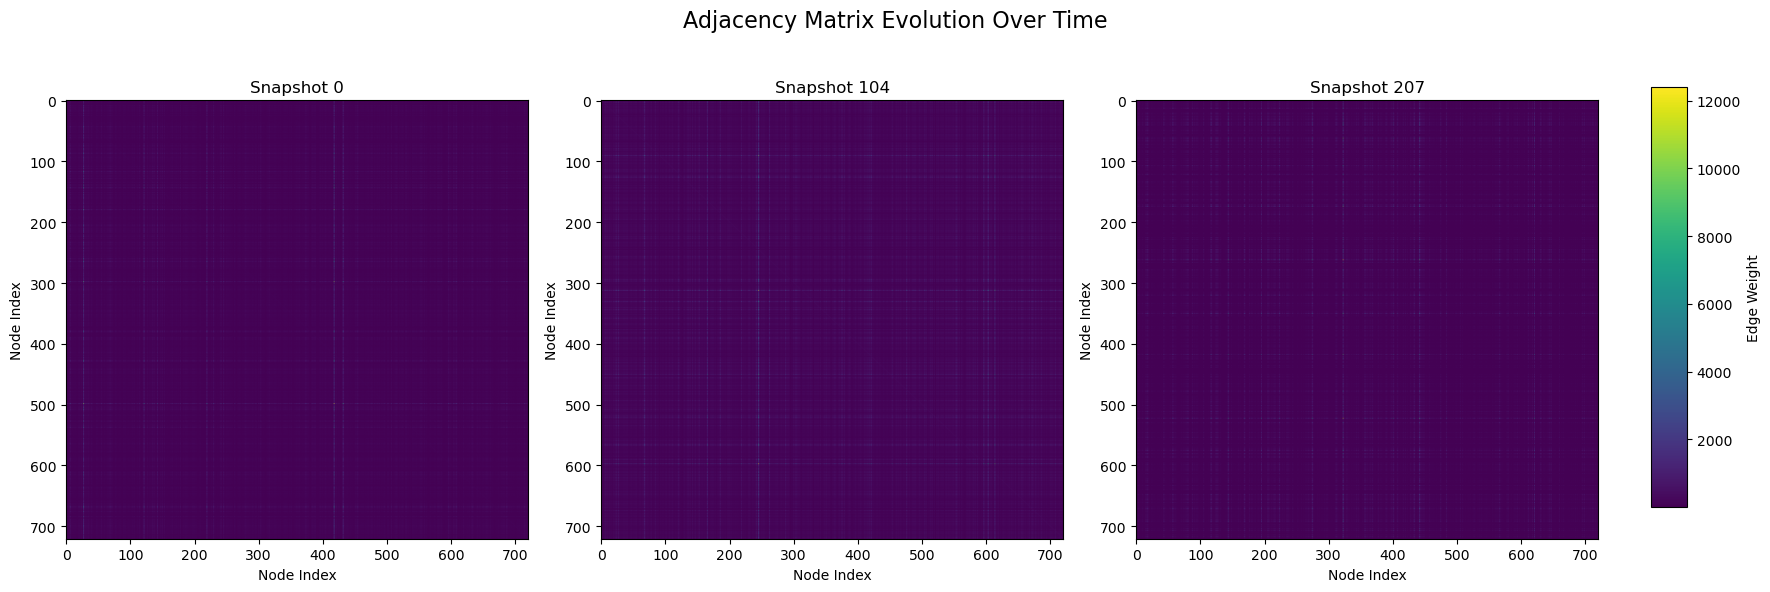

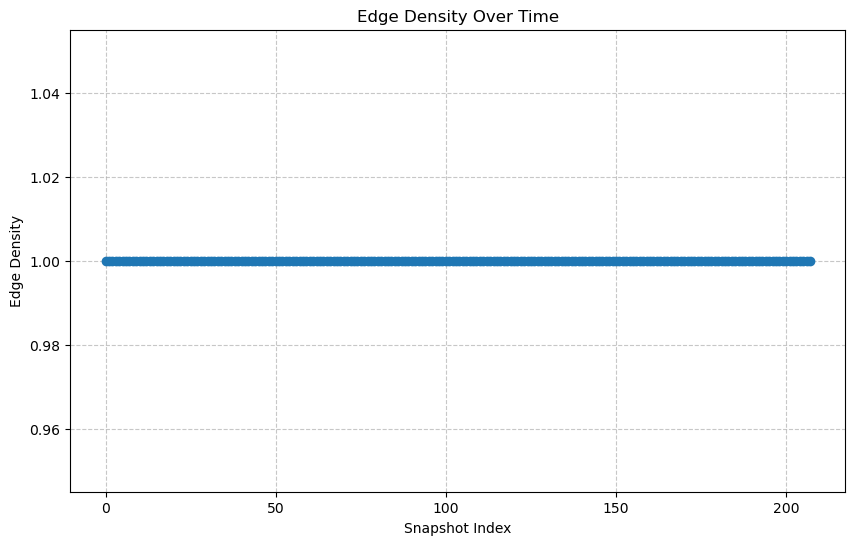

In [30]:
# Compare adjacency matrices at different time points
if len(adj_matrices) >= 3:
    snapshot_indices = [0, len(adj_matrices)//2, len(adj_matrices)-1]  # First, middle, last
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for i, idx in enumerate(snapshot_indices):
        im = axes[i].imshow(adj_matrices[idx], cmap='viridis', aspect='auto')
        axes[i].set_title(f'Snapshot {idx}')
        axes[i].set_xlabel('Node Index')
        axes[i].set_ylabel('Node Index')
    
    # Add colorbar to the right of the last image
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Edge Weight')
    
    plt.suptitle('Adjacency Matrix Evolution Over Time', fontsize=16)
    plt.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()
    
    # Analyze how edge density changes over time
    edge_density = [np.count_nonzero(adj)/adj.size for adj in adj_matrices]
    plt.figure(figsize=(10, 6))
    plt.plot(edge_density, 'o-')
    plt.title('Edge Density Over Time')
    plt.xlabel('Snapshot Index')
    plt.ylabel('Edge Density')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

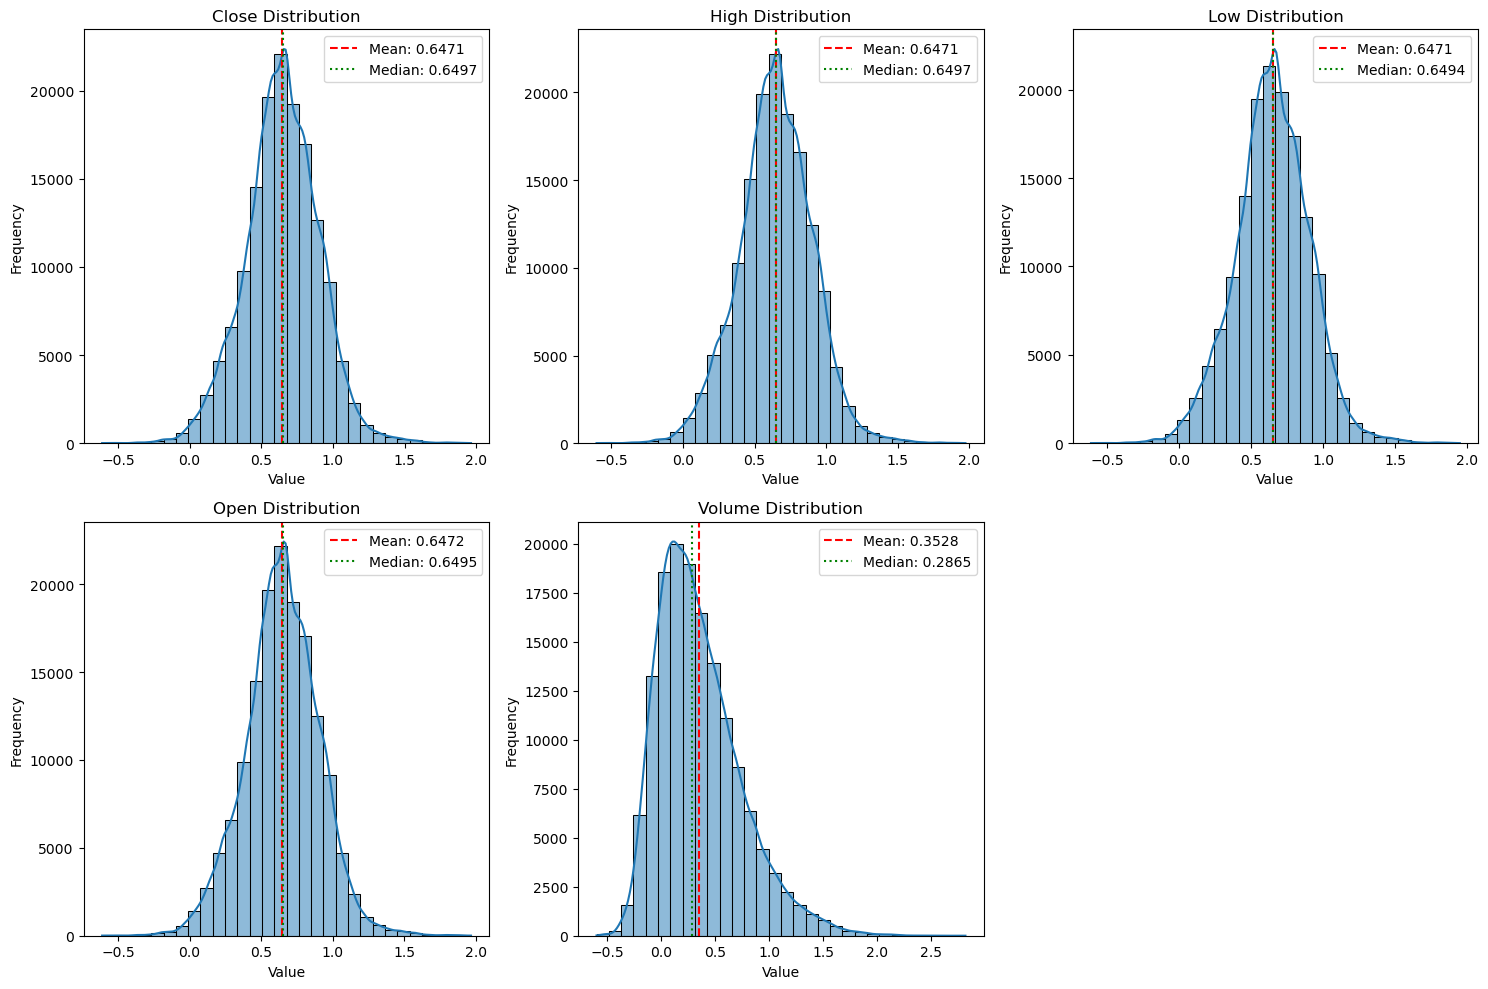

,Close,High,Low,Open,Volume
count,149968.000000,149968.000000,149968.000000,149968.000000,149968.000000
mean,0.647062,0.647072,0.647093,0.647212,0.352781
std,0.257332,0.257395,0.257399,0.257758,0.385763
min,-0.610874,-0.603349,-0.614386,-0.611282,-0.600062
25%,0.488963,0.488895,0.489366,0.489281,0.069976
50%,0.649679,0.649703,0.649373,0.649545,0.286488
75%,0.814252,0.814218,0.814445,0.814868,0.569508
max,1.963282,1.972878,1.949265,1.964577,2.819087


In [31]:
# Get raw feature data for analysis
train_features_df = train_analyzer.analyze_node_features()

# Plot distribution of each feature
plt.figure(figsize=(15, 10))
for i, feature in enumerate(train_analyzer.features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(train_features_df[feature], kde=True, bins=30)
    plt.title(f'{feature} Distribution')
    plt.xlabel('Value')
    plt.ylabel('Frequency')
    # Add mean and median lines
    plt.axvline(train_features_df[feature].mean(), color='red', linestyle='--', 
                label=f'Mean: {train_features_df[feature].mean():.4f}')
    plt.axvline(train_features_df[feature].median(), color='green', linestyle=':', 
                label=f'Median: {train_features_df[feature].median():.4f}')
    plt.legend()
plt.tight_layout()
plt.show()

# Calculate summary statistics for features
feature_stats_df = train_features_df[train_analyzer.features].describe()
feature_stats_df

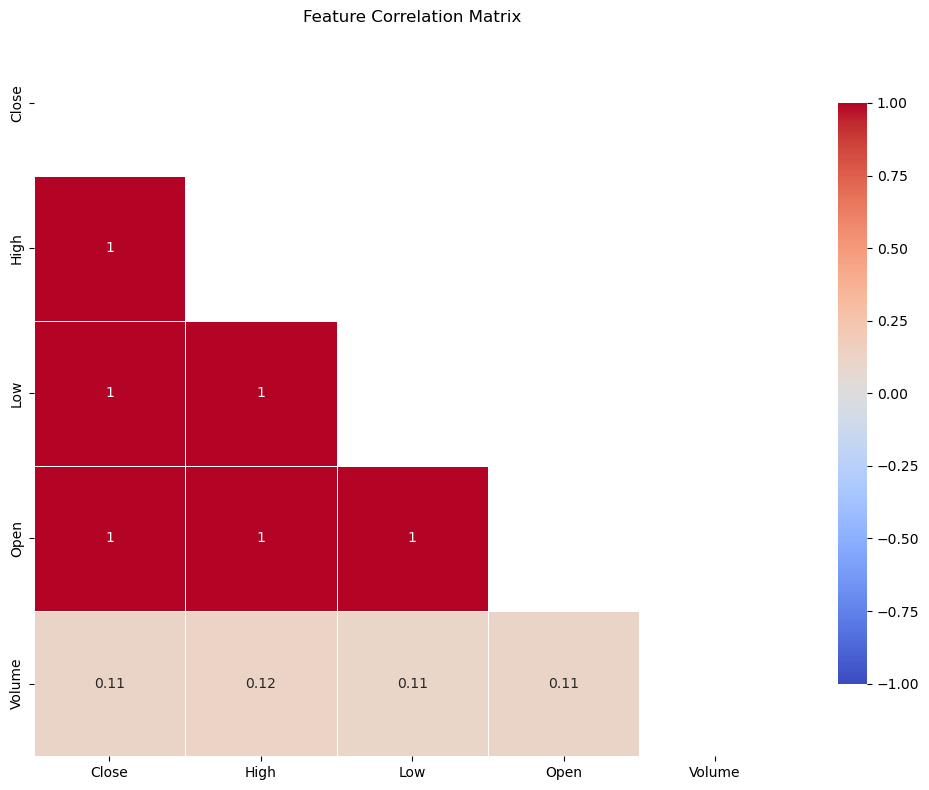

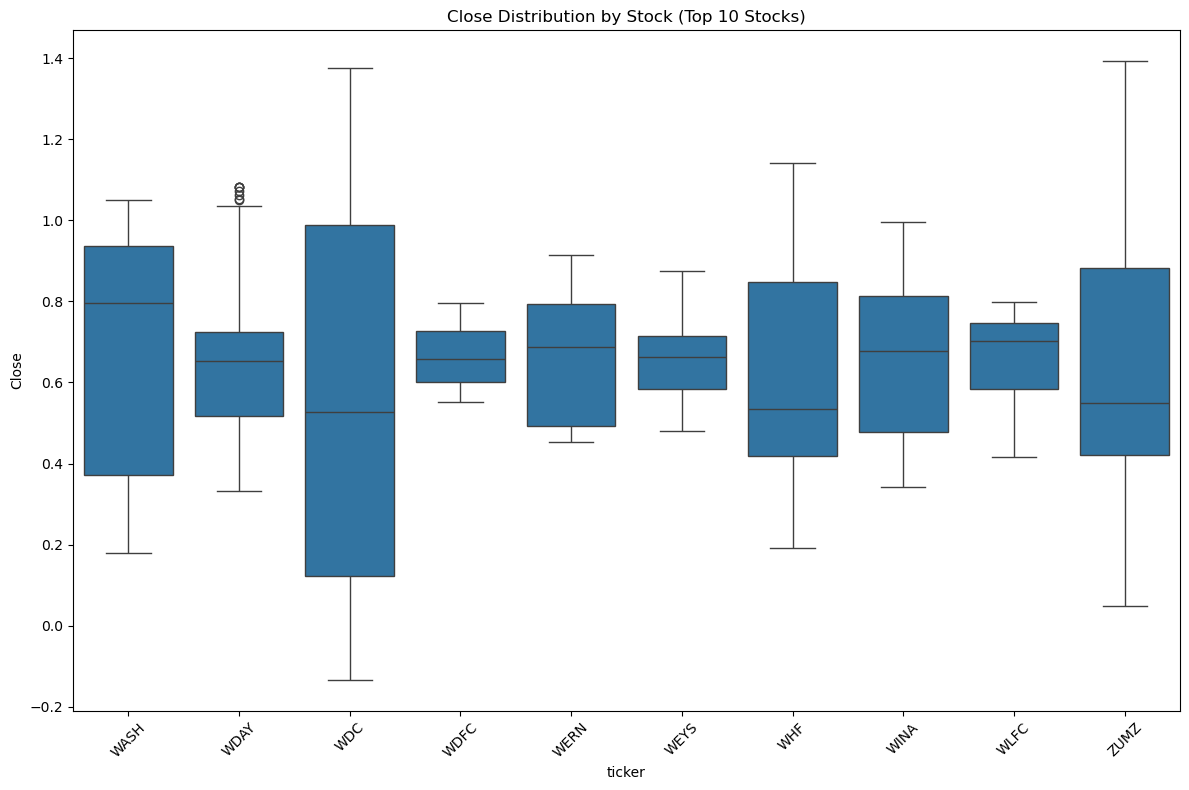

In [ ]:
# Analyze correlations between features
plt.figure(figsize=(10, 8))
corr_matrix = train_features_df[train_analyzer.features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
           linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Analyze how features vary by ticker (showing top 10 stocks for clarity)
top_stocks = train_features_df['ticker'].value_counts().head(10).index.tolist()
top_stocks_data = train_features_df[train_features_df['ticker'].isin(top_stocks)]

plt.figure(figsize=(12, 8))
feature_to_plot = 'Close'  # You can change this to any feature
sns.boxplot(x='ticker', y=feature_to_plot, data=top_stocks_data)
plt.xticks(rotation=45)
plt.title(f'{feature_to_plot} Distribution by Stock (Top 10 Stocks)')
plt.tight_layout()
plt.show()

## Homophily Analysis
Calculate and visualize homophily for each snapshot (fraction of edges connecting nodes with the same label).

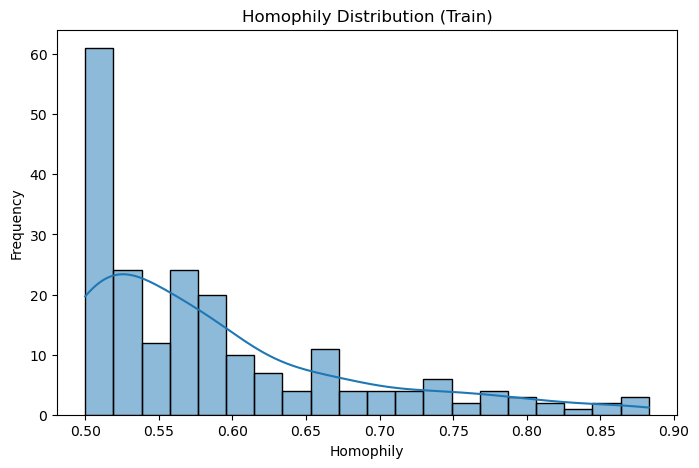

In [33]:
homophily_scores = []

analyzer = train_analyzer

for sample_idx in range(len(analyzer.graph_snapshots)):
    homophily_score = analyzer.get_homophily_score(sample_idx)
    homophily_scores.append(homophily_score)


plt.figure(figsize=(8, 5))
sns.histplot(homophily_scores, bins=20, kde=True)
plt.title('Homophily Distribution (Train)')
plt.xlabel('Homophily')
plt.ylabel('Frequency')
plt.show()

## Feature-Target Correlation Analysis
Analyze the relationship between node features and their corresponding labels (up/down movement).

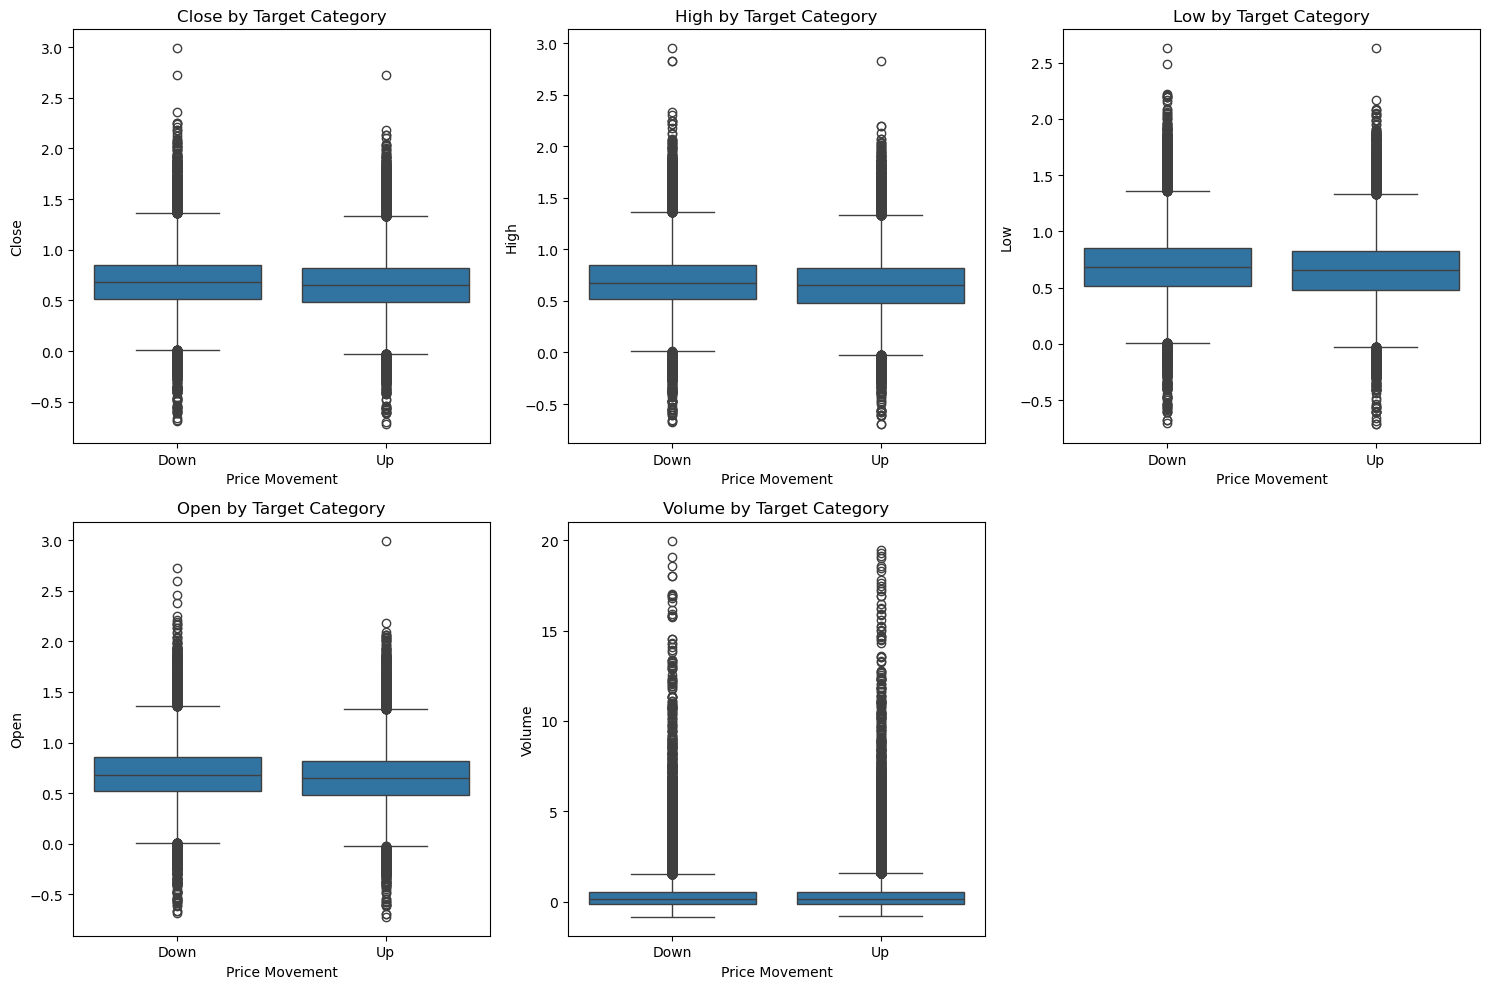

Average feature values by target category:


,Close,High,Low,Open,Volume
target_category,,,,,
Down,0.685354,0.684519,0.685156,0.684859,0.339684
Up,0.651598,0.652354,0.652102,0.652509,0.362387


In [34]:
# Collect features and labels from snapshots
features_list = []
labels_list = []

for i in range(train_analyzer.num_snapshots):
    snapshot = train_analyzer.graph_snapshots[i]
    features = snapshot.x
    
    # Handle different feature shapes
    if features.dim() == 3:
        # Take the last time step for each node
        features = features[:, -1, :] 
    elif features.dim() == 2 and features.shape[1] > train_analyzer.num_features:
        # Reshape if needed
        features = features.reshape(features.shape[0], -1, train_analyzer.num_features)
        features = features[:, -1, :]
    
    features_np = features.numpy()
    labels_np = snapshot.y.numpy()
    
    features_list.append(features_np)
    labels_list.append(labels_np)

# Combine all snapshots
all_features = np.vstack(features_list)
all_labels = np.hstack(labels_list)

# Create a DataFrame with features and labels
feature_target_df = pd.DataFrame(all_features, columns=train_analyzer.features)
feature_target_df['target'] = all_labels
feature_target_df['target_category'] = np.where(feature_target_df['target'] > 0, 'Up', 'Down')

# Visualize feature distributions by target category
plt.figure(figsize=(15, 10))
for i, feature in enumerate(train_analyzer.features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='target_category', y=feature, data=feature_target_df)
    plt.title(f'{feature} by Target Category')
    plt.xlabel('Price Movement')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

# Calculate mean values by target category
feature_by_target = feature_target_df.groupby('target_category')[train_analyzer.features].mean()
print("Average feature values by target category:")
display(feature_by_target)

## Up Ratios Analysis
Visualize the distribution of up ratios (fraction of nodes with positive label) for each dataset.

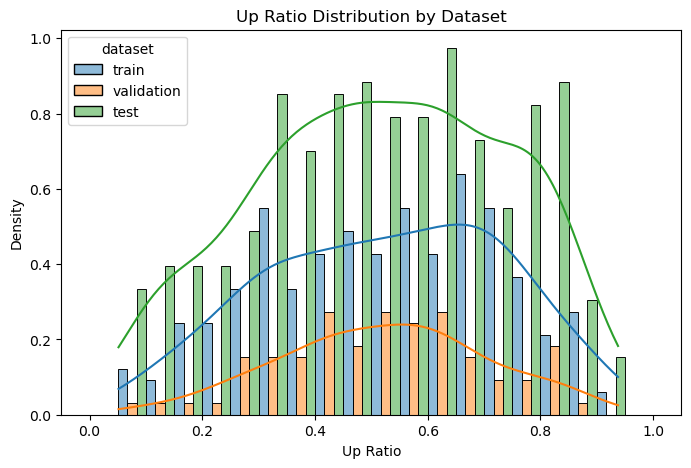

In [35]:
plt.figure(figsize=(8, 5))
sns.histplot(data=all_snapshots_df, x='up_ratio', hue='dataset', multiple='dodge', kde=True, binrange=(0, 1), binwidth=.05, stat='density')
plt.title('Up Ratio Distribution by Dataset')
plt.xlabel('Up Ratio')
plt.ylabel('Density')
plt.show()

## Connectivity Analysis
Compare connectivity statistics across datasets.

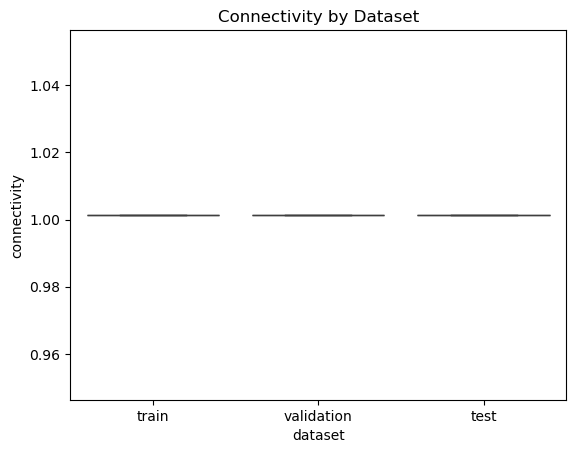

In [37]:
sns.boxplot(data=all_snapshots_df, x='dataset', y='connectivity')
plt.title('Connectivity by Dataset')
plt.show()

## Summary Statistics
Show summary statistics for key metrics in each dataset.

In [ ]:
summary = all_snapshots_df.groupby('dataset')[['up_ratio', 'connectivity']].describe()
summary

up_ratio                                                    \
              count      mean       std       min       25%       50%   
dataset                                                                 
test          474.0  0.467333  0.264069  0.007812  0.257812  0.429688   
train         271.0  0.467683  0.212914  0.054688  0.308594  0.445312   
validation    112.0  0.457450  0.155254  0.062500  0.363281  0.453125   

                               connectivity                                    \
                 75%       max        count      mean           std       min   
dataset                                                                         
test        0.669922  1.000000        474.0  1.007874  1.555954e-15  1.007874   
train       0.601562  0.992188        271.0  1.007874  1.557188e-15  1.007874   
validation  0.564453  0.929688        112.0  1.007874  1.561298e-15  1.007874   

                                                    
                 25%       50%       75%       max  
dataset                                             
test        1.007874  1.007874  1.007874  1.007874  
train       1.007874  1.007874  1.007874  1.007874  
validation  1.007874  1.007874  1.007874  1.007874

## Dataset Analysis Summary

This comprehensive analysis of the temporal graph datasets reveals several key insights:

### Adjacency Matrix Insights
- **Edge weights**: The edge weights in our adjacency matrices represent correlation strengths between stock price movements
- **Density**: We've analyzed the edge density across snapshots and observed its temporal evolution
- **Distribution**: The distribution of edge weights provides insights into the overall market connectivity

### Node Feature Insights
- **Feature distributions**: We've analyzed the statistical properties of node features across all snapshots
- **Feature correlations**: We've identified correlations between different features
- **Feature-target relationships**: We've examined how features differ between stocks with positive and negative price movements

### Graph Structure Insights
- **Homophily**: We've measured the tendency of connected stocks to have the same price movement direction
- **Connectivity**: We've compared connectivity across different datasets and time periods
- **Up ratio distribution**: We've analyzed the balance between positive and negative price movements across datasets

This analysis provides a solid foundation for understanding the datasets used in our temporal graph neural network models.